# Customer Churn Prediction using ANN-Deep Learning

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [4]:
label_encoder = LabelEncoder()
df["Geography"] = label_encoder.fit_transform(df["Geography"])
df["Gender"] = label_encoder.fit_transform(df["Gender"])

In [6]:
x = df.drop("Exited", axis=1).values
y = df["Exited"].values

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [10]:
model = models.Sequential(
    [
        layers.Input(shape=(x_train.shape[1],)),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(
            1, activation="sigmoid"
        ), 
    ]
)

model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

In [11]:
history = model.fit(
    x_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1
)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7642 - loss: 0.5156 - val_accuracy: 0.8062 - val_loss: 0.4516
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7969 - loss: 0.4550 - val_accuracy: 0.8163 - val_loss: 0.4241
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8081 - loss: 0.4320 - val_accuracy: 0.8275 - val_loss: 0.4072
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8265 - loss: 0.4138 - val_accuracy: 0.8450 - val_loss: 0.3962
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8368 - loss: 0.3977 - val_accuracy: 0.8450 - val_loss: 0.3838
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8453 - loss: 0.3835 - val_accuracy: 0.8537 - val_loss: 0.3733
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8522 - loss: 0.3727 - val_accuracy: 0.8525 - val_loss: 0.3650
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8544 - loss: 0.3643 - val_accuracy: 0.

In [13]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

In [14]:
test_loss

0.33781957626342773

In [15]:
test_acc

0.8619999885559082

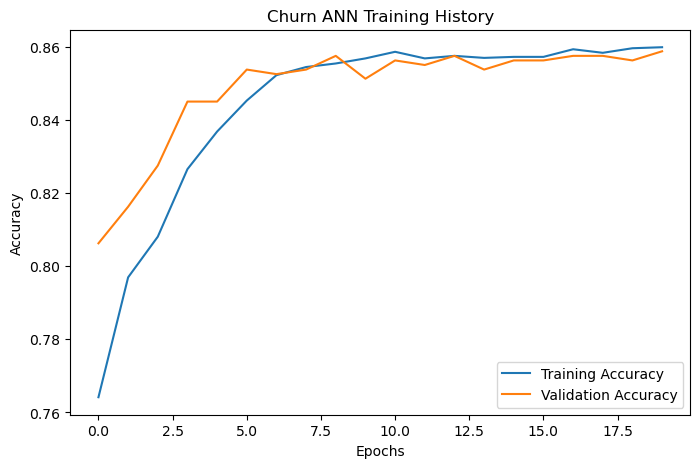

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Churn ANN Training History")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [17]:
model.save("churn_ann_model.h5")